In [5]:
import numpy as np
import matplotlib.pyplot as plt
import requests
from PIL import Image
from io import BytesIO
from machine_learning import k_means

In [6]:
def plot_colors(colors):
    plt.figure(figsize=(10, 2))
    for i, color in enumerate(colors):
        plt.fill_between([i, i+1], 0, 1, color=np.array(color)/255.0)
    plt.axis('off')
    plt.title('Dominant Colors Palette')
    plt.show()

def plot_img(img_url):
    response = requests.get(img_url)
    img = Image.open(BytesIO(response.content)).resize((224, 224))

    plt.imshow(img)
    plt.axis('off')
    plt.title('Input Image (224x224)')
    plt.show()


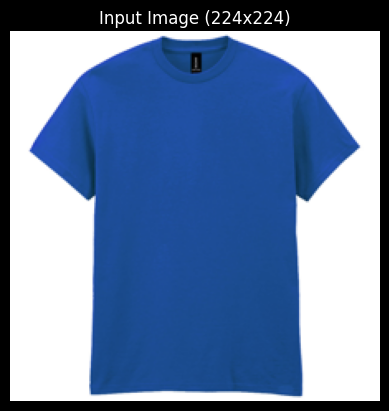

In [7]:
TEST_URL = 'https://www.militarykit.com/cdn/shop/files/mens-gildan-short-sleeve-heavy-cotton-tshirt-royal-blue.jpg?v=1766053652&width=1500'

plot_img(TEST_URL)

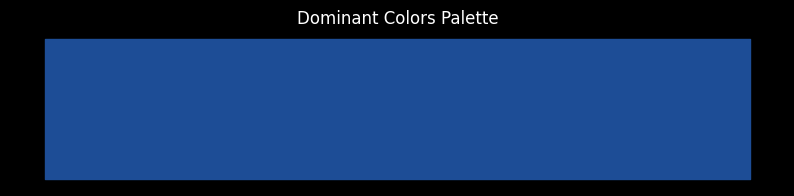

[[29, 77, 150]]


In [10]:
from aux_functions.auxiliary import download_image

img_array = download_image(TEST_URL)
name, rgb_list = k_means.predict_k_colors(img_array)
plot_colors(rgb_list)
print(rgb_list)

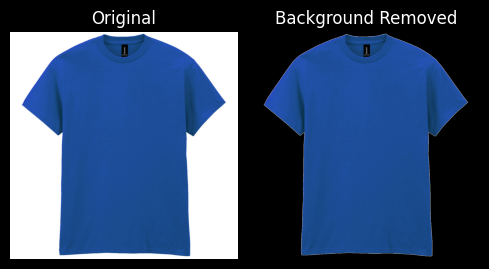

In [11]:
from aux_functions.auxiliary import remove_specific_color_background

result = remove_specific_color_background(img_array)

fig, axes = plt.subplots(1, 2, figsize=(5, 5))
axes[0].imshow(img_array)
axes[0].set_title("Original")
axes[0].axis("off")

axes[1].imshow(result)
axes[1].set_title("Background Removed")
axes[1].axis("off")

plt.tight_layout()
plt.show()